In [1]:
import os
import json
import random
import shutil

from PIL import Image
from tqdm import tqdm
from collections import Counter
from collections import defaultdict

## add T or F for black color

In [2]:
DATA_DIR = "symbols_dataset"

with open(f"{DATA_DIR}/labels.json", "r") as f:
    labels = json.load(f)

print(list(labels.items())[:5])

[('symbol_1.png', '5'), ('symbol_10.png', '2'), ('symbol_100.png', '8'), ('symbol_1000.png', '2'), ('symbol_1001.png', '5')]


In [3]:
BLACK_CARDS = {"+4", "wild"}

new_labels = {}

for img_name, label in labels.items():
    new_labels[img_name] = {
        "label": label,
        "is_black": label in BLACK_CARDS
    }

print(list(new_labels.items())[:5])

[('symbol_1.png', {'label': '5', 'is_black': False}), ('symbol_10.png', {'label': '2', 'is_black': False}), ('symbol_100.png', {'label': '8', 'is_black': False}), ('symbol_1000.png', {'label': '2', 'is_black': False}), ('symbol_1001.png', {'label': '5', 'is_black': False})]


In [4]:
OUT_DIR = "augm_symbols_dataset"

with open(f"{OUT_DIR}/labels.json", "w") as f:
    json.dump(new_labels, f, indent=2)

## count symbols

In [5]:
OUT_DIR = "augm_symbols_dataset"

with open(f"{OUT_DIR}/labels.json", "r") as f:
    labels = json.load(f)

In [6]:
class_counts = Counter()

for img, info in labels.items():
    class_counts[info["label"]] += 1

In [7]:
for label, count in sorted(class_counts.items()):
    print(label, count)

0 54
1 69
2 96
3 85
4 107
5 84
6 68
7 123
8 104
9 48
draw_2 62
draw_4 23
reverse 60
skip 62
wild 45


90-10% for testing and training

In [8]:
by_class = defaultdict(list)

for img, info in labels.items():
    by_class[info["label"]].append(img)

In [9]:
train_labels = {}
test_labels = {}

random.seed(42)  # reproducibility

for label, images in by_class.items():
    random.shuffle(images)

    n_test = int(len(images) * 0.1)
    
    test_imgs = images[:n_test]
    train_imgs = images[n_test:]

    for img in train_imgs:
        train_labels[img] = labels[img]

    for img in test_imgs:
        test_labels[img] = labels[img]

In [10]:
print("Total:", len(labels))
print("Train:", len(train_labels))
print("Test:", len(test_labels))

Total: 1090
Train: 988
Test: 102


In [11]:
with open(f"{OUT_DIR}/train.json", "w") as f:
    json.dump(train_labels, f, indent=2)

with open(f"{OUT_DIR}/test.json", "w") as f:
    json.dump(test_labels, f, indent=2)

## augment training dataset

In [12]:
DATA_DIR = "symbols_dataset"
OUT_DIR = "augm_symbols_dataset"

os.makedirs(OUT_DIR, exist_ok=True)

In [13]:
with open(f"{OUT_DIR}/train.json", "r") as f:
    train_labels = json.load(f)

In [14]:
for img_name in tqdm(list(train_labels.keys())):
    src = os.path.join(DATA_DIR, img_name)
    dst = os.path.join(OUT_DIR, img_name)

    if not os.path.exists(dst):
        shutil.copy(src, dst)

100%|███████████████████████████████████████████████████████████████████████████████████| 988/988 [00:00<00:00, 3011.19it/s]


In [15]:
def augment_image(img):
    # random rotation
    angle = random.uniform(0, 360)

    # random translation
    tx = random.uniform(-10, 10)
    ty = random.uniform(-10, 10)

    img = img.rotate(angle, resample=Image.BILINEAR)

    img = img.transform(
        img.size,
        Image.AFFINE,
        (1, 0, tx, 0, 1, ty),
        resample=Image.BILINEAR
    )

    return img

example avec rotations et translations

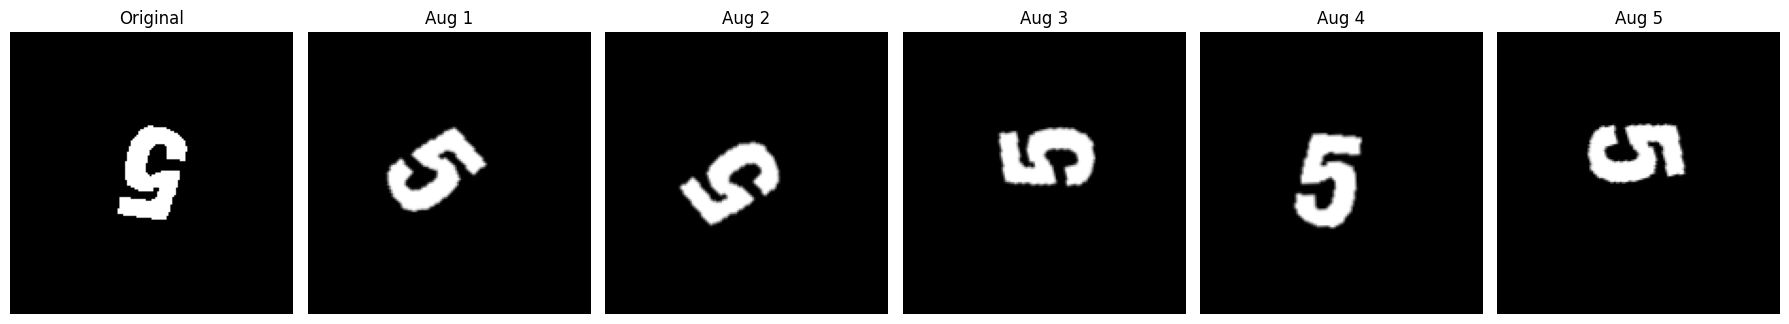

In [16]:
import matplotlib.pyplot as plt

sample_img_name = list(train_labels.keys())[0]

# load original image
img = Image.open(os.path.join(DATA_DIR, sample_img_name)).convert("RGB")

# create augmented versions
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# show original
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

# show 5 augmentations
for i in range(5):
    aug = augment_image(img)

    axes[i + 1].imshow(aug)
    axes[i + 1].set_title(f"Aug {i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

example avec rotations multiples de 90 et translations

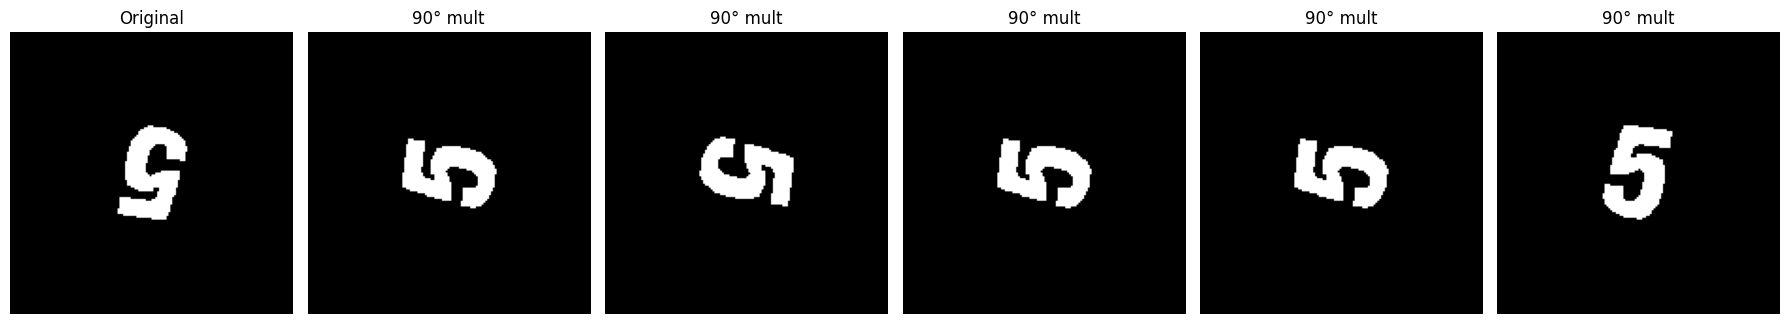

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def augment_90(img):
    angle = random.choice([0, 90, 180, 270])
    return img.rotate(angle)

sample_img_name = list(train_labels.keys())[0]

# load original image
img = Image.open(os.path.join(DATA_DIR, sample_img_name)).convert("RGB")

# display
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

# original
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")

# augmentations
for i in range(5):
    aug = augment_90(img)

    axes[i + 1].imshow(aug)
    axes[i + 1].set_title("90° mult")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

## augmentation

In [18]:
DATA_DIR = "symbols_dataset"
OUT_DIR = "augm_symbols_dataset"

TRAIN_TARGET = 400
TEST_TARGET = 44

# ----------------------------
# LOAD SPLIT (original labels)
# ----------------------------

with open(f"{OUT_DIR}/train.json", "r") as f:
    train_labels = json.load(f)

with open(f"{OUT_DIR}/test.json", "r") as f:
    test_labels = json.load(f)

# ----------------------------
# GROUP BY CLASS
# ----------------------------

def group_by_class(labels):
    d = defaultdict(list)
    for img, info in labels.items():
        d[info["label"]].append(img)
    return d

train_by_class = group_by_class(train_labels)
test_by_class = group_by_class(test_labels)

classes = sorted(train_by_class.keys())

# ----------------------------
# PRINT ORIGINAL DISTRIBUTION
# ----------------------------

def print_dist(name, labels):
    c = Counter([v["label"] for v in labels.values()])
    total = sum(c.values())
    print(f"\n{name}")
    for k in sorted(c.keys()):
        print(f"{k}: {c[k]} ({c[k]/total:.3f})")
    print("TOTAL:", total)

print_dist("TRAIN original", train_labels)
print_dist("TEST original", test_labels)

# ----------------------------
# AUGMENTATION FUNCTION
# ----------------------------

def augment_image(img):
    angle = random.uniform(0, 360)
    tx = random.uniform(-10, 10)
    ty = random.uniform(-10, 10)

    img = img.rotate(angle)
    img = img.transform(
        img.size,
        Image.AFFINE,
        (1, 0, tx, 0, 1, ty)
    )
    return img

# ----------------------------
# FIND START INDEX
# ----------------------------

max_index = 0
for f in list(train_labels.keys()) + list(test_labels.keys()):
    try:
        max_index = max(max_index, int(f.replace("symbol_", "").replace(".png", "")))
    except:
        pass

new_index = max_index + 1

# ----------------------------
# OUTPUT LABELS (we KEEP originals + add new ones)
# ----------------------------

new_train = dict(train_labels)
new_test = dict(test_labels)

# ----------------------------
# TRAIN COMPLETION (ONLY MISSING DATA)
# ----------------------------

print("\nGenerating TRAIN (completion mode)...")

for c in classes:
    imgs = train_by_class[c]

    current_count = len(imgs)
    needed = max(0, TRAIN_TARGET - current_count)

    print(f"Class {c}: {current_count} → adding {needed}")

    for _ in tqdm(range(needed)):
        src = random.choice(imgs)

        img = Image.open(os.path.join(DATA_DIR, src)).convert("RGB")
        aug = augment_image(img)

        name = f"symbol_{new_index}.png"
        aug.save(os.path.join(OUT_DIR, name))

        new_train[name] = train_labels[src]
        new_index += 1

# ----------------------------
# TEST COMPLETION (ONLY MISSING DATA)
# ----------------------------

print("\nGenerating TEST (completion mode)...")

for c in classes:
    imgs = test_by_class[c]

    current_count = len(imgs)
    needed = max(0, TEST_TARGET - current_count)

    print(f"Class {c}: {current_count} → adding {needed}")

    for _ in tqdm(range(needed)):
        src = random.choice(imgs)

        img = Image.open(os.path.join(DATA_DIR, src)).convert("RGB")
        aug = augment_image(img)

        name = f"symbol_{new_index}.png"
        aug.save(os.path.join(OUT_DIR, name))

        new_test[name] = test_labels[src]
        new_index += 1

# ----------------------------
# SAVE JSONS
# ----------------------------

with open(f"{OUT_DIR}/train.json", "w") as f:
    json.dump(new_train, f, indent=2)

with open(f"{OUT_DIR}/test.json", "w") as f:
    json.dump(new_test, f, indent=2)

# ----------------------------
# FINAL STATS
# ----------------------------

def stats(name, labels):
    c = Counter([v["label"] for v in labels.values()])
    total = sum(c.values())

    print(f"\n{name} FINAL")
    for k in sorted(c.keys()):
        print(f"{k}: {c[k]} ({c[k]/total:.3f})")
    print("TOTAL:", total)

stats("TRAIN", new_train)
stats("TEST", new_test)


TRAIN original
0: 49 (0.050)
1: 63 (0.064)
2: 87 (0.088)
3: 77 (0.078)
4: 97 (0.098)
5: 76 (0.077)
6: 62 (0.063)
7: 111 (0.112)
8: 94 (0.095)
9: 44 (0.045)
draw_2: 56 (0.057)
draw_4: 21 (0.021)
reverse: 54 (0.055)
skip: 56 (0.057)
wild: 41 (0.041)
TOTAL: 988

TEST original
0: 5 (0.049)
1: 6 (0.059)
2: 9 (0.088)
3: 8 (0.078)
4: 10 (0.098)
5: 8 (0.078)
6: 6 (0.059)
7: 12 (0.118)
8: 10 (0.098)
9: 4 (0.039)
draw_2: 6 (0.059)
draw_4: 2 (0.020)
reverse: 6 (0.059)
skip: 6 (0.059)
wild: 4 (0.039)
TOTAL: 102

Generating TRAIN (completion mode)...
Class 0: 49 → adding 351


100%|████████████████████████████████████████████████████████████████████████████████████| 351/351 [00:00<00:00, 690.98it/s]


Class 1: 63 → adding 337


100%|████████████████████████████████████████████████████████████████████████████████████| 337/337 [00:00<00:00, 769.48it/s]


Class 2: 87 → adding 313


...

Class skip: 6 → adding 38


100%|██████████████████████████████████████████████████████████████████████████████████████| 38/38 [00:00<00:00, 669.41it/s]


Class wild: 4 → adding 40


100%|██████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 613.80it/s]


TRAIN FINAL
0: 400 (0.067)
1: 400 (0.067)
2: 400 (0.067)
3: 400 (0.067)
4: 400 (0.067)
5: 400 (0.067)
6: 400 (0.067)
7: 400 (0.067)
8: 400 (0.067)
9: 400 (0.067)
draw_2: 400 (0.067)
draw_4: 400 (0.067)
reverse: 400 (0.067)
skip: 400 (0.067)
wild: 400 (0.067)
TOTAL: 6000

TEST FINAL
0: 44 (0.067)
1: 44 (0.067)
2: 44 (0.067)
3: 44 (0.067)
4: 44 (0.067)
5: 44 (0.067)
6: 44 (0.067)
7: 44 (0.067)
8: 44 (0.067)
9: 44 (0.067)
draw_2: 44 (0.067)
draw_4: 44 (0.067)
reverse: 44 (0.067)
skip: 44 (0.067)
wild: 44 (0.067)
TOTAL: 660
